# POC não supervisionada: tipos de praça para vender fiança

**Beatriz Babinski** · Projeto em Ciência de Dados V · IBMEC

Pergunta: *onde colocar o próximo R$ 1 em mídia paga?*

Este notebook **apresenta** os resultados. Todo o cálculo está em `src/.../poc_clusters/` e roda com `make poc`.

In [1]:
import pandas as pd
from pathlib import Path
from IPython.display import Image, display, Markdown

pd.set_option('display.width', 200)
pd.set_option('display.max_colwidth', 70)

RAIZ = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
TABELAS = RAIZ / 'reports' / 'tables'
FIGURAS = RAIZ / 'reports' / 'figures'

def tabela(nome):
    return pd.read_csv(TABELAS / f'{nome}.csv')

def figura(nome):
    display(Image(filename=str(FIGURAS / f'{nome}.png')))

## 1. As fontes e a data de referência de cada variável

Regra do projeto: nada anterior a 2025, e nenhum uso do Censo 2022.

In [2]:
tabela('02_fontes_data_referencia')[['rotulo','fonte','data_referencia','entra_no_cluster']]

,rotulo,fonte,data_referencia,entra_no_cluster
0,Administradoras de imóveis / 10 mil hab.,"Receita Federal - CNPJ, CNAE 6822600 (Base dos Dados)",2026-01-11,True
1,Crédito sobre poupança (alavancagem),"Banco Central - ESTBAN, crédito sobre poupança e depósito a prazo ...",2025-09,True
2,Banda larga fixa / 100 hab.,Anatel - densidade de banda larga fixa por município (Base dos Dados),2025-09,True
3,Famílias no CadÚnico / 100 domicílios,Ministério do Desenvolvimento e Assistência Social - Cadastro Únic...,2026-09,True
4,Corretores de seguros / 10 mil hab.,"Receita Federal - CNPJ, CNAE 6622300 (Base dos Dados)",2026-01-11,True
5,Crédito per capita (R$),"Banco Central - ESTBAN, verbete 160 operações de crédito (Base dos...",2025-09,True
6,Crescimento da população em 1 ano (%),"IBGE - Estimativas da população, dois anos consecutivos (tabela SI...",2026-07-01,True
7,Imobiliárias e corretoras / 10 mil hab.,"Receita Federal - CNPJ, CNAE 6821801 (Base dos Dados)",2026-01-11,True
8,Imobiliárias novas em 12 meses (%),"Receita Federal - CNPJ, CNAE 6821 e 6822 (Base dos Dados)",2026-01-11,True
9,Internet móvel 4G/5G de pessoa física / 100 hab.,Anatel - acessos de telefonia móvel por município e tecnologia (da...,2026-07,True


## 2. A base está usável?

687 municípios com 50 mil habitantes ou mais, pela estimativa do IBGE de 2026.

In [3]:
tabela('01_cobertura_variaveis')[['rotulo','faltantes','faltantes_pct','zeros','mediana','maximo','assimetria']]

,rotulo,faltantes,faltantes_pct,zeros,mediana,maximo,assimetria
0,Administradoras de imóveis / 10 mil hab.,0,0.0,45,1.226,22.132,3.86
1,Imobiliárias e corretoras / 10 mil hab.,0,0.0,31,2.433,150.379,11.29
2,Imobiliárias novas em 12 meses (%),0,0.0,95,12.867,100.000,2.42
3,Pix de pessoa física por habitante,0,0.0,0,55191.163,135731.284,0.93
4,Salário mediano de admissão (R$),0,0.0,0,1720.000,2575.800,0.45
5,Famílias no CadÚnico / 100 domicílios,0,0.0,0,51.983,118.975,0.26
6,Crédito per capita (R$),0,0.0,0,9695.813,1007843.288,20.24
7,Veículos por habitante,0,0.0,0,0.291,0.762,-0.09
8,Saldo de emprego / admissões em 12 meses (%),0,0.0,1,4.762,47.215,-0.34
9,Internet móvel 4G/5G de pessoa física / 100 hab.,0,0.0,0,90.979,127.912,-0.58


## 3. Estatística descritiva

O que a distribuição de cada variável exigiu: log onde a cauda é longa.

In [4]:
tabela('03_estatistica_descritiva')[['rotulo','media','desvio_padrao','coef_variacao','mediana','p99','maximo','assimetria','aplicar_log']]

,rotulo,media,desvio_padrao,coef_variacao,mediana,p99,maximo,assimetria,aplicar_log
0,Administradoras de imóveis / 10 mil hab.,1.7028,1.8225,1.0703,1.2256,7.7045,2.213230e+01,3.8640,True
1,Imobiliárias e corretoras / 10 mil hab.,4.2007,7.8684,1.8731,2.4328,25.0163,1.503793e+02,11.2906,True
2,Imobiliárias novas em 12 meses (%),13.5992,9.8549,0.7247,12.8672,50.0000,1.000000e+02,2.4151,True
3,Pix de pessoa física por habitante,56897.7150,16078.9949,0.2826,55191.1633,106999.7314,1.357313e+05,0.9269,False
4,Salário mediano de admissão (R$),1781.9086,210.4256,0.1181,1720.0000,2204.0636,2.575800e+03,0.4500,False
5,Famílias no CadÚnico / 100 domicílios,55.1047,22.1569,0.4021,51.9830,102.4132,1.189755e+02,0.2556,False
6,Crédito per capita (R$),14506.0371,42063.3764,2.8997,9695.8128,58663.7542,1.007843e+06,20.2429,True
7,Veículos por habitante,0.2867,0.1453,0.5066,0.2914,0.5431,7.622000e-01,-0.0924,False
8,Saldo de emprego / admissões em 12 meses (%),5.7838,8.2227,1.4217,4.7618,29.8901,4.721470e+01,-0.3431,False
9,Internet móvel 4G/5G de pessoa física / 100 hab.,89.2639,14.7860,0.1656,90.9787,122.7915,1.279125e+02,-0.5758,False


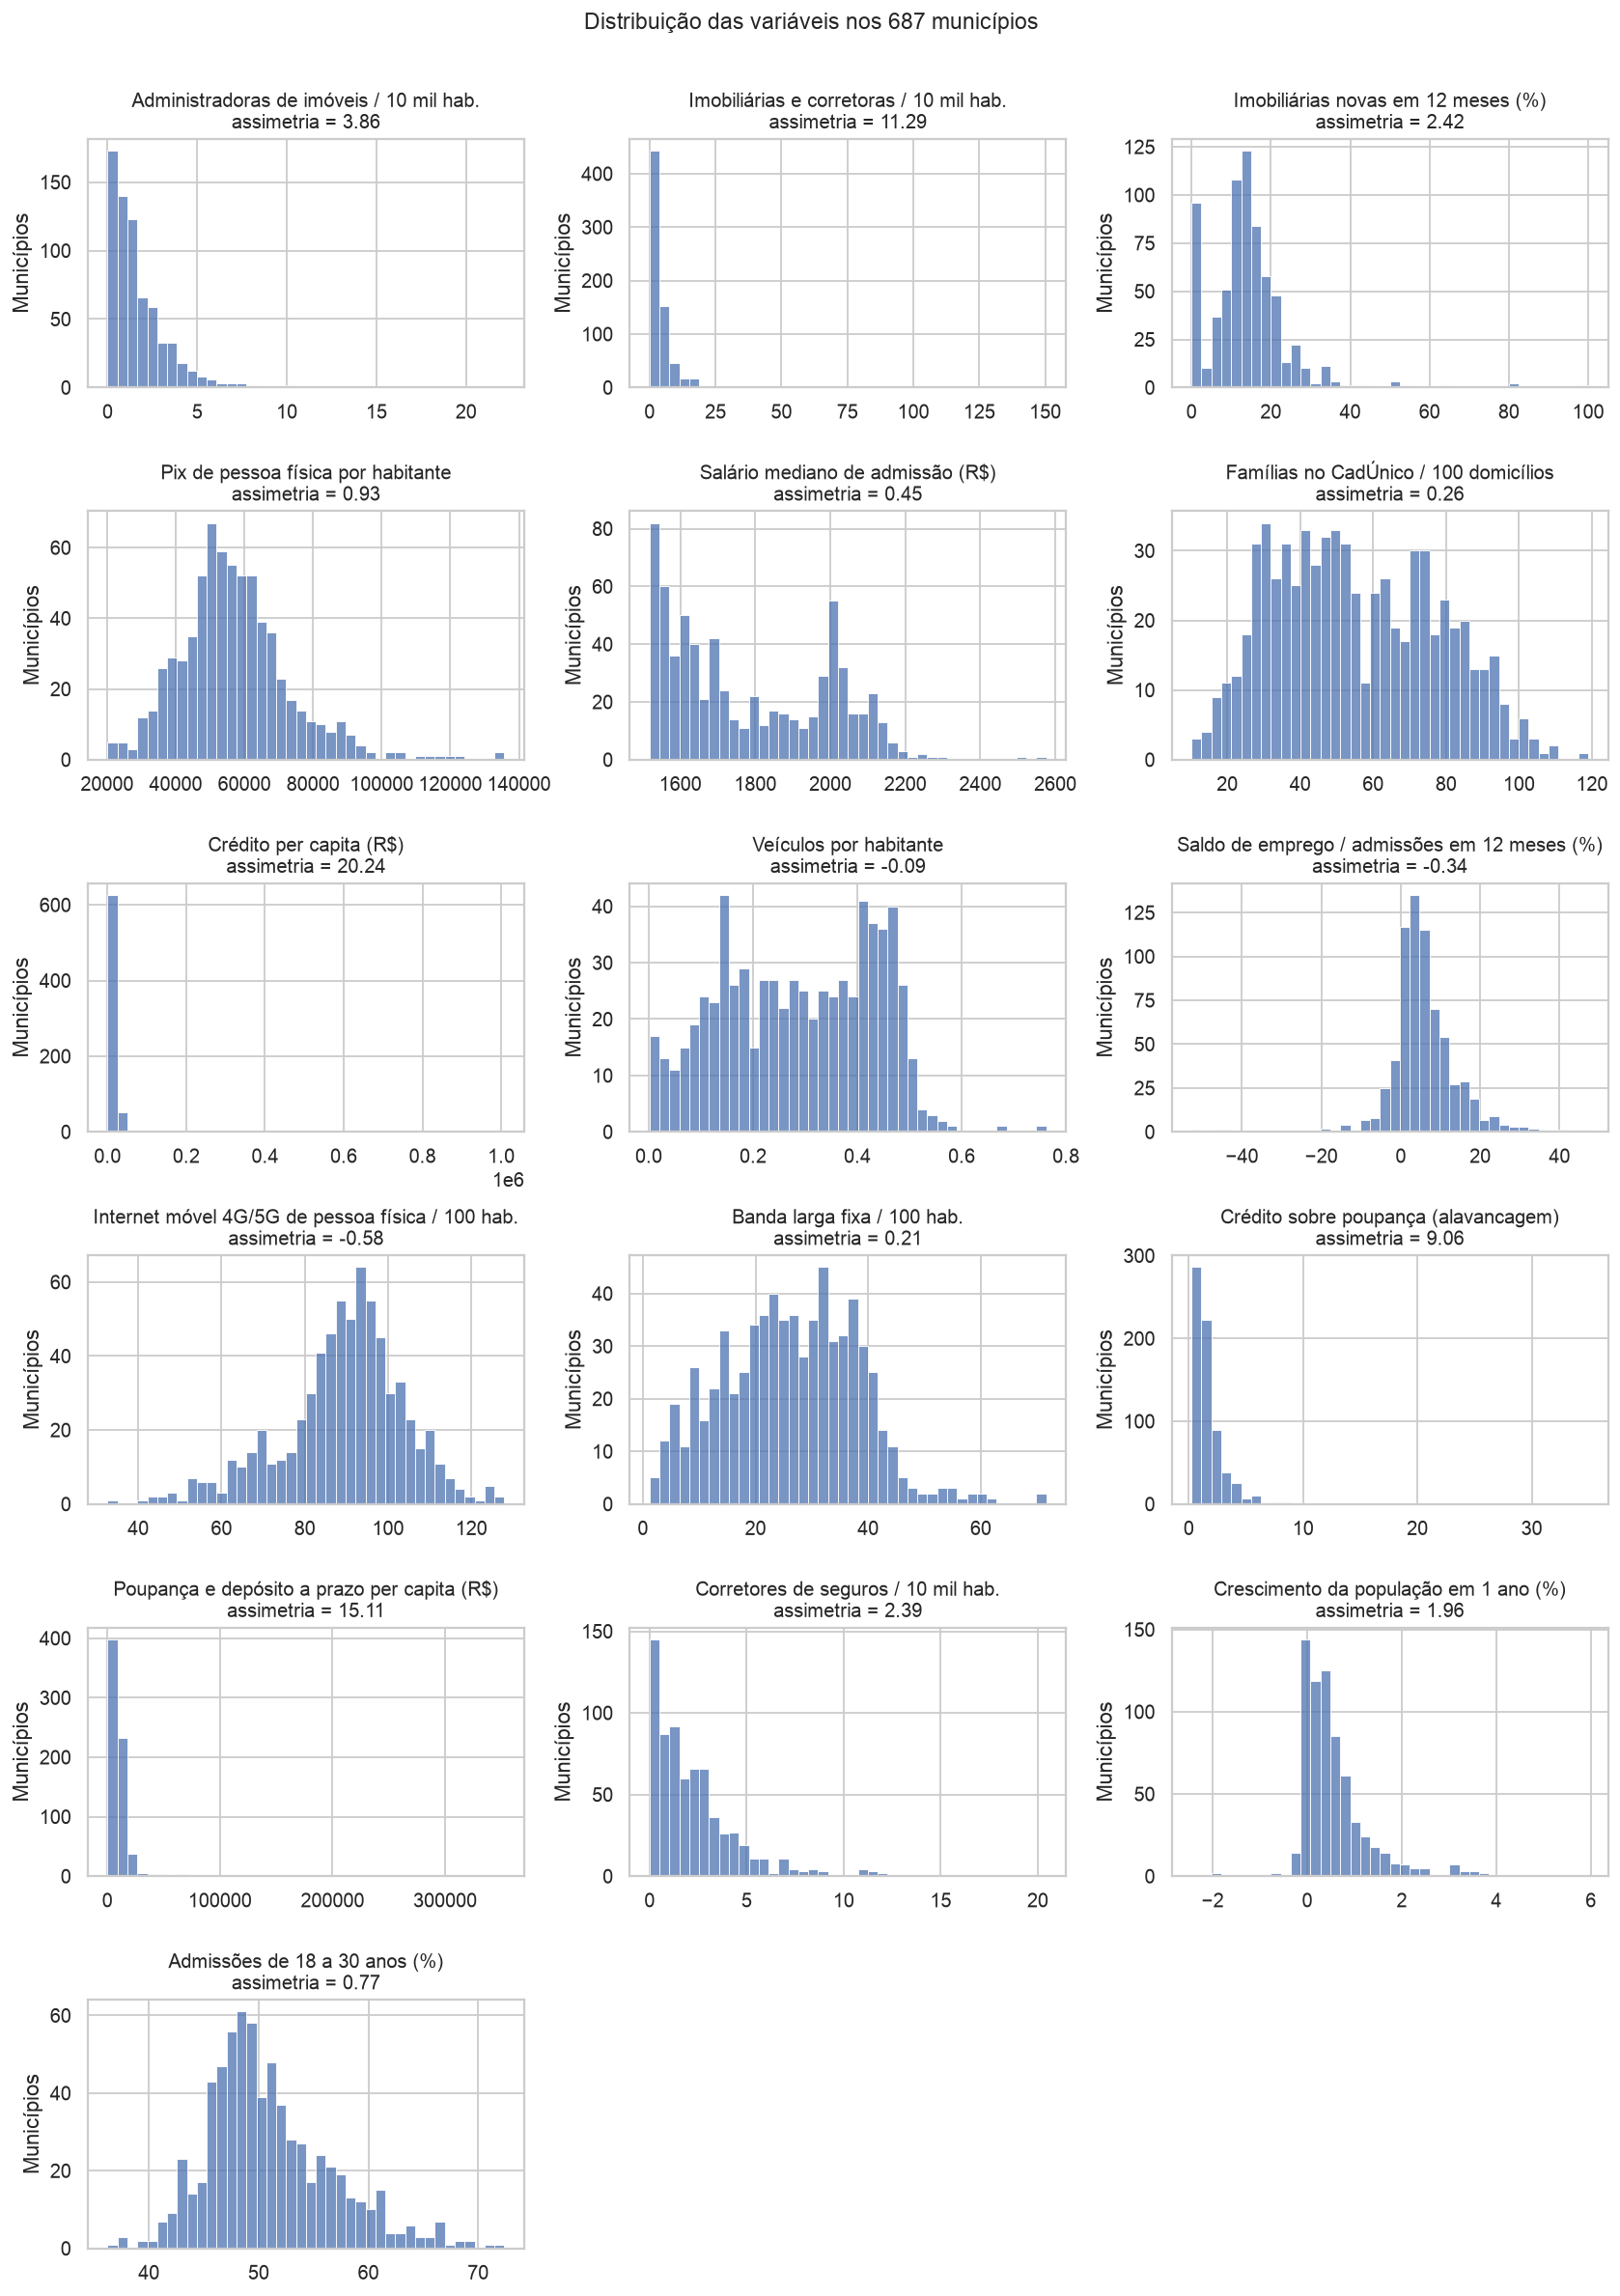

In [5]:
figura('01_histogramas')

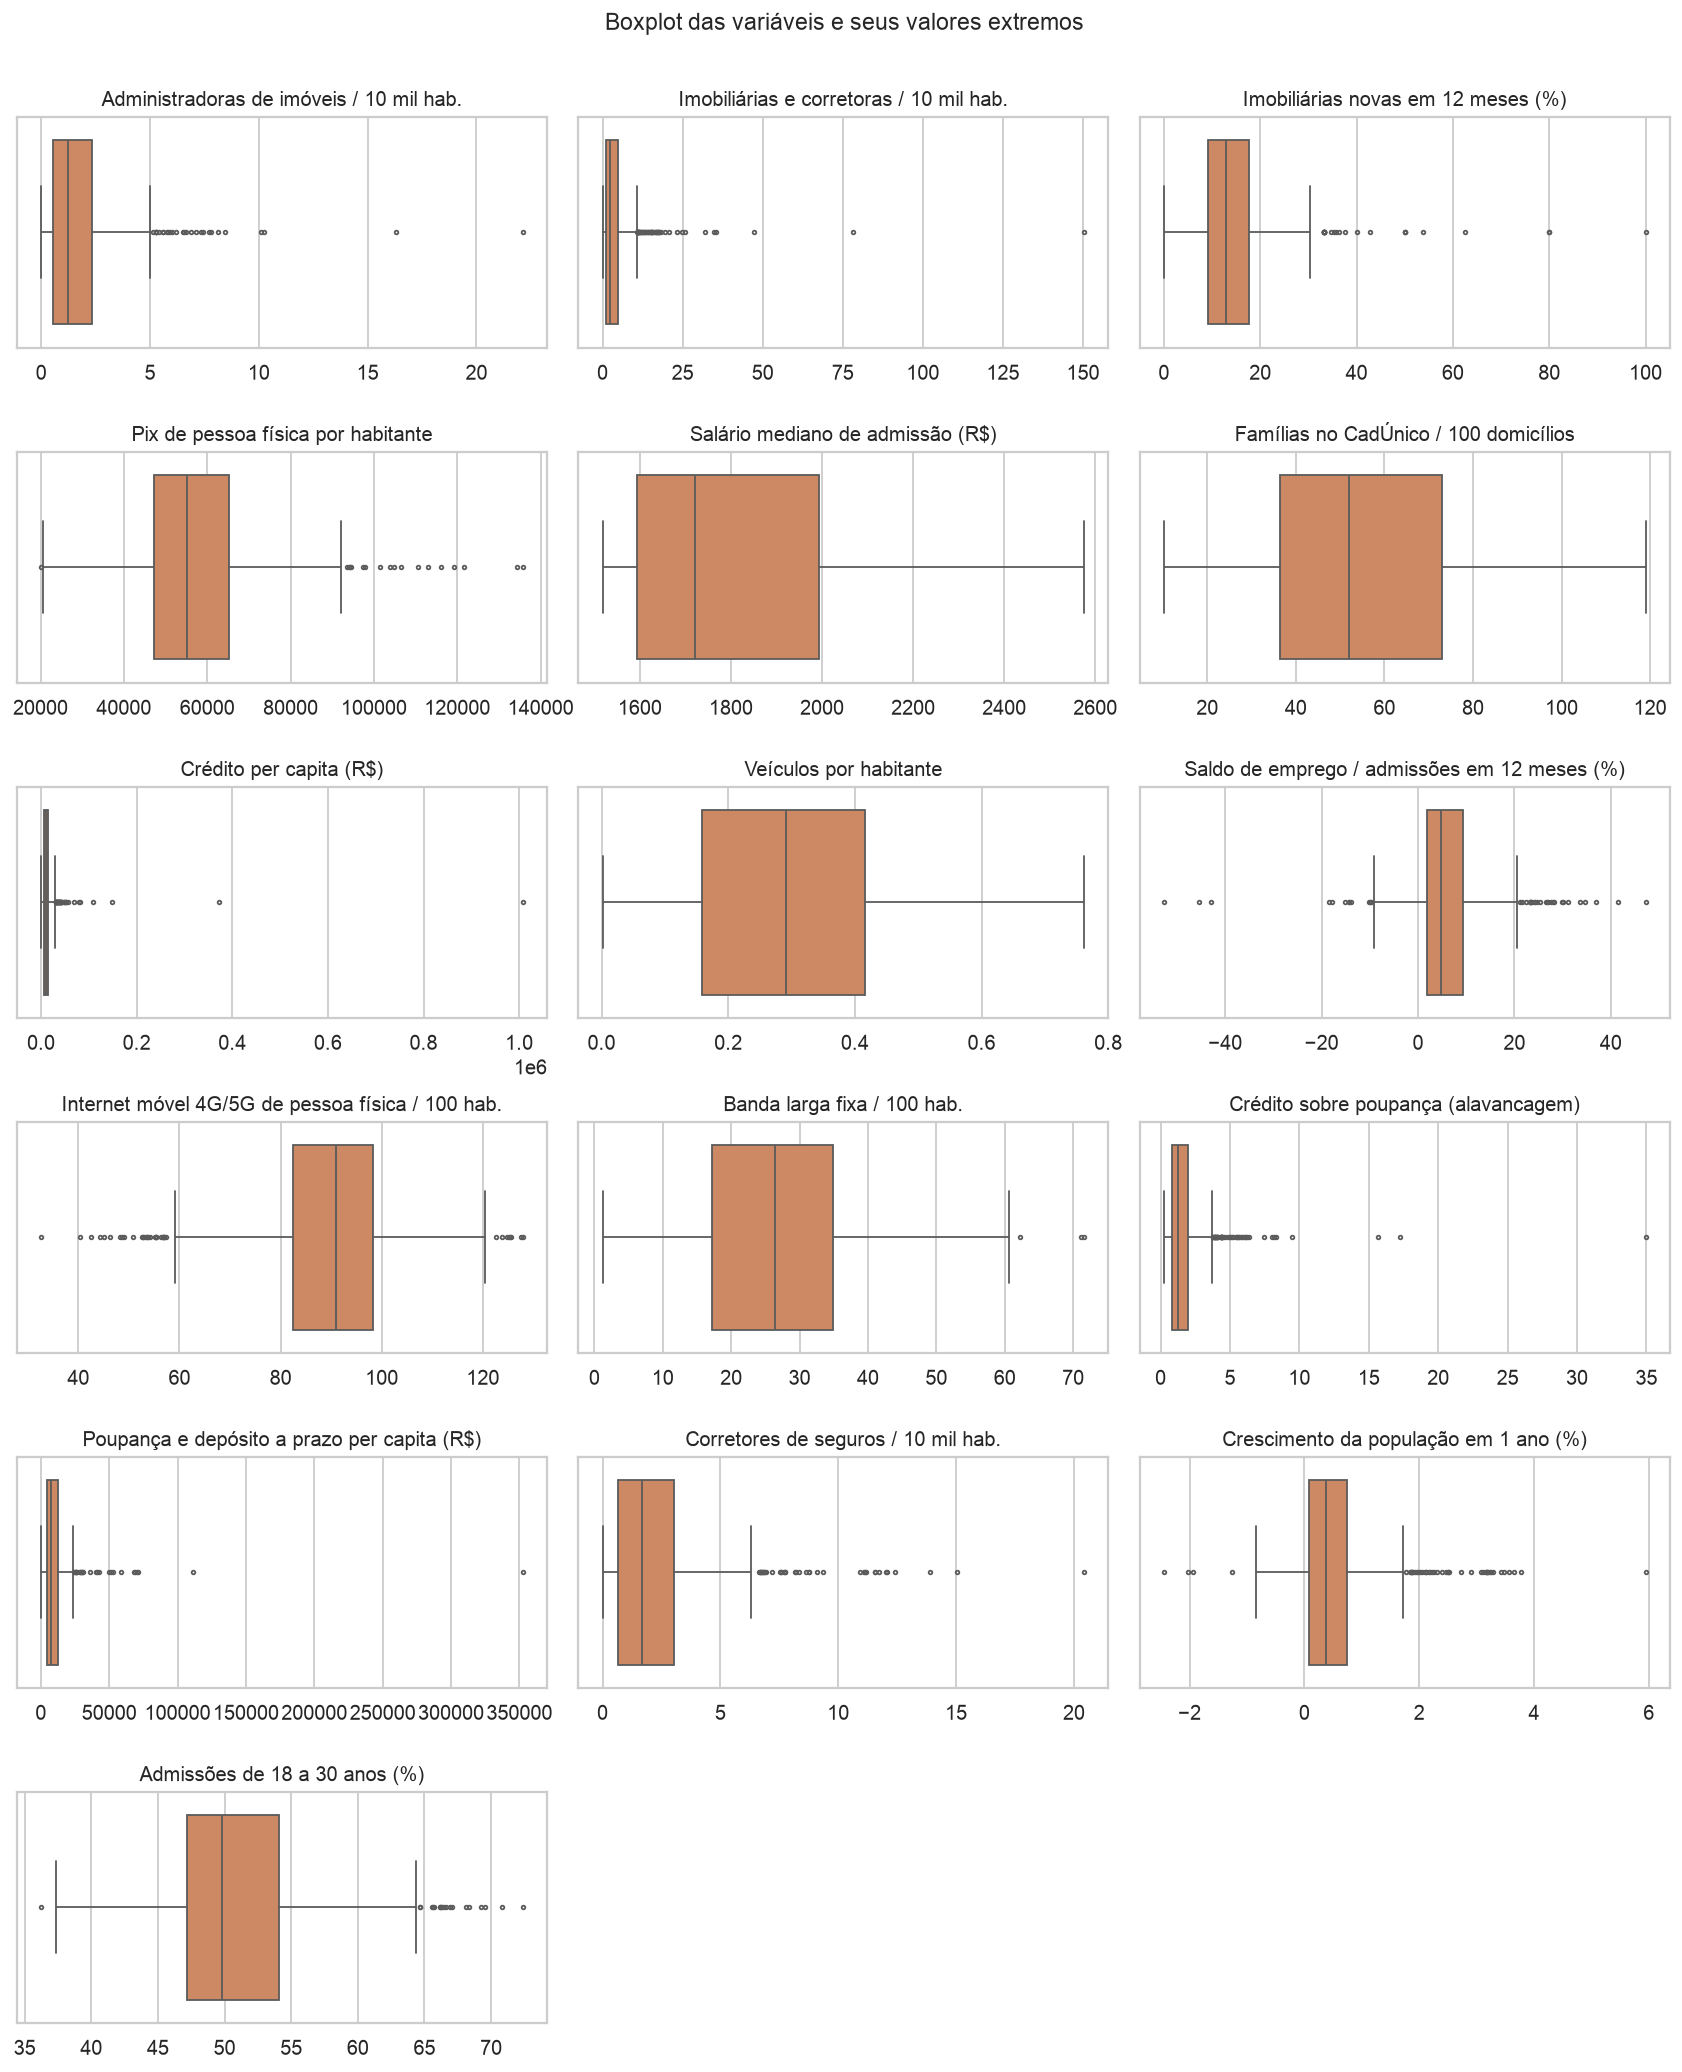

In [6]:
figura('02_boxplots')

### Winsorização

Corte de 1% nas duas caudas. Foi necessário porque algumas fontes registram a operação onde a empresa está sediada, e não onde o cliente mora.

In [7]:
tabela('04_winsorizacao')[['rotulo','limite_superior','municipios_cortados_acima','assimetria_antes','assimetria_depois']]

,rotulo,limite_superior,municipios_cortados_acima,assimetria_antes,assimetria_depois
0,Administradoras de imóveis / 10 mil hab.,7.705,7,3.86,1.62
1,Imobiliárias e corretoras / 10 mil hab.,25.016,7,11.29,2.33
2,Imobiliárias novas em 12 meses (%),50.000,5,2.42,0.95
3,Pix de pessoa física por habitante,106999.731,7,0.93,0.64
4,Salário mediano de admissão (R$),2204.064,7,0.45,0.35
5,Famílias no CadÚnico / 100 domicílios,102.413,7,0.26,0.24
6,Crédito per capita (R$),58663.754,7,20.24,2.04
7,Veículos por habitante,0.543,7,-0.09,-0.16
8,Saldo de emprego / admissões em 12 meses (%),29.890,7,-0.34,0.67
9,Internet móvel 4G/5G de pessoa física / 100 hab.,122.791,7,-0.58,-0.53


## 4. Correlação, VIF e corte de variáveis

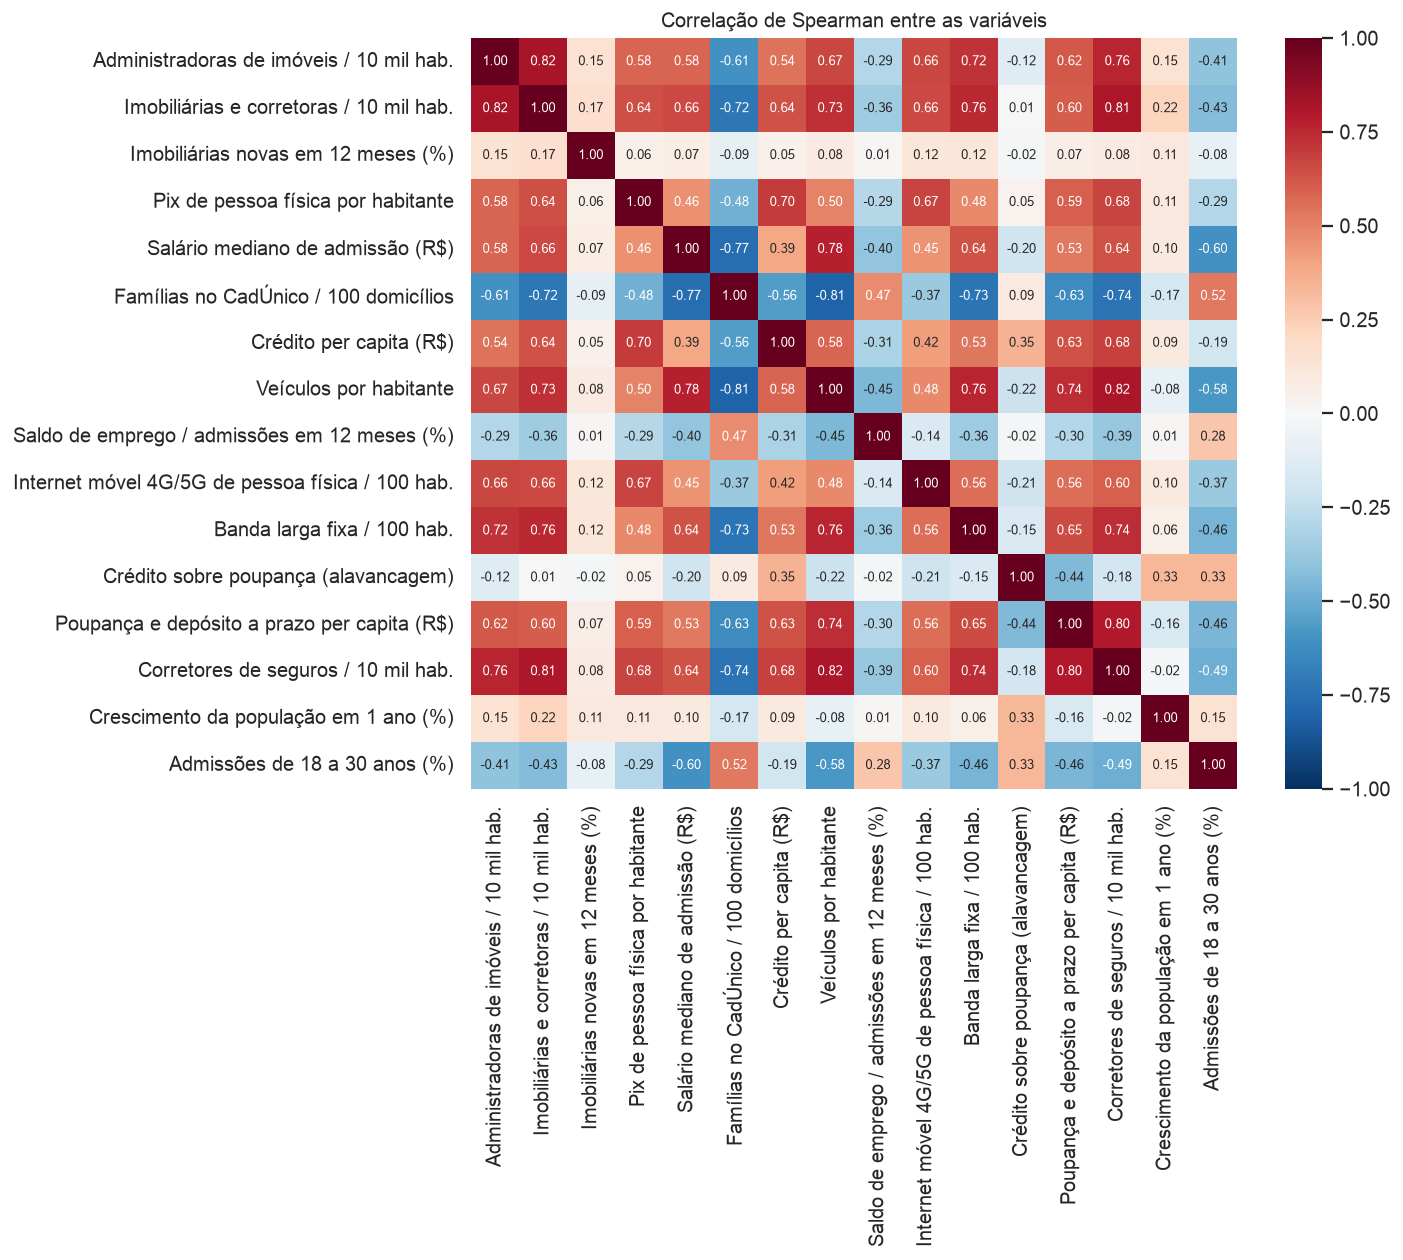

In [8]:
figura('03_correlacao')

In [9]:
tabela('06_vif')[['rotulo','vif']]

,rotulo,vif
0,Veículos por habitante,6.56
1,Famílias no CadÚnico / 100 domicílios,4.55
2,Crédito per capita (R$),4.46
3,Corretores de seguros / 10 mil hab.,4.22
4,Poupança e depósito a prazo per capita (R$),3.92
5,Administradoras de imóveis / 10 mil hab.,3.58
6,Imobiliárias e corretoras / 10 mil hab.,3.36
7,Banda larga fixa / 100 hab.,3.36
8,Pix de pessoa física por habitante,3.34
9,Salário mediano de admissão (R$),3.15


Pares acima de 0,80 em módulo: fica só uma variável. O desempate é relevância de negócio, depois VIF.

In [10]:
tabela('07_cortes_de_variaveis')[['rotulo_descartada','rotulo_mantida','correlacao_spearman','motivo']]

,rotulo_descartada,rotulo_mantida,correlacao_spearman,motivo
0,Imobiliárias e corretoras / 10 mil hab.,Administradoras de imóveis / 10 mil hab.,0.824,correlação de 0.82 acima do limiar de 0.80; usada em 4 dos 4 grupo...
1,Veículos por habitante,Famílias no CadÚnico / 100 domicílios,0.810,saiu numa cadeia de variáveis correlacionadas entre si; a sobreviv...
2,Corretores de seguros / 10 mil hab.,Poupança e depósito a prazo per capita (R$),0.802,"correlação de 0.80 acima do limiar de 0.80; mesmo peso no desenho,..."


## 5. Escolha de k

**Achado desconfortável:** a silhueta é máxima em k = 2 em quase tudo e cai a partir daí. O Brasil municipal é um contínuo socioeconômico, não um conjunto de grupos cravados. Por isso k sai do cotovelo da inércia, e a qualidade é julgada pelos baselines.

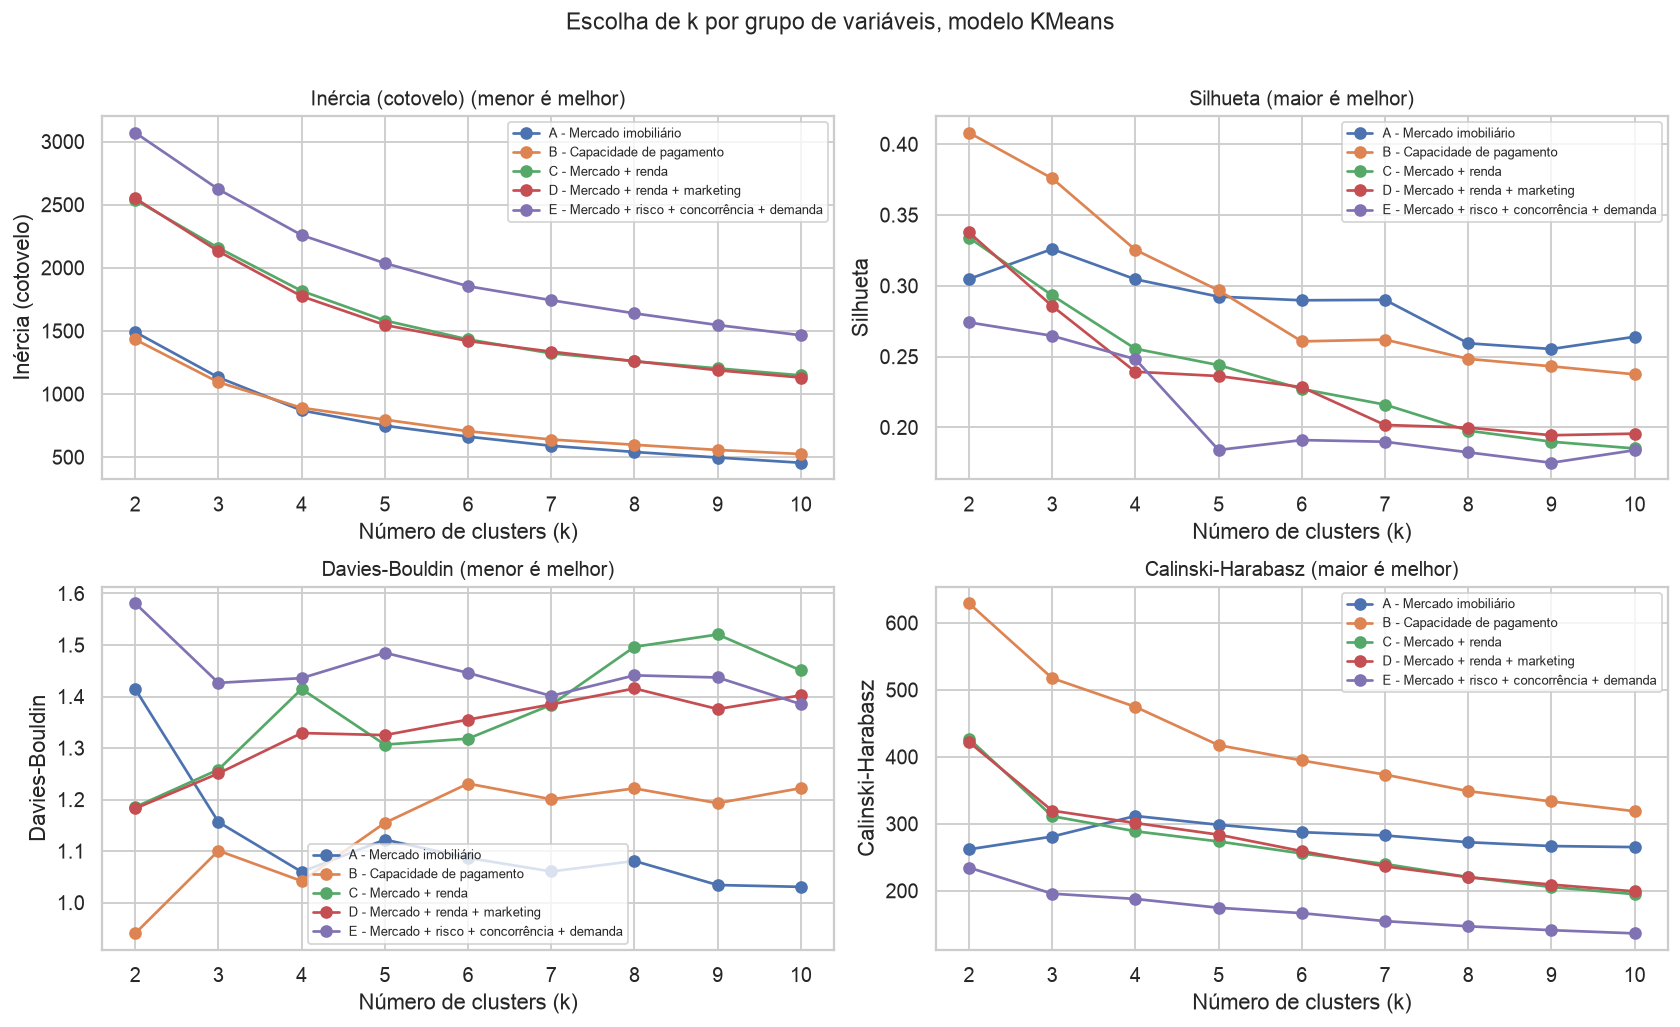

In [11]:
figura('04_escolha_de_k')

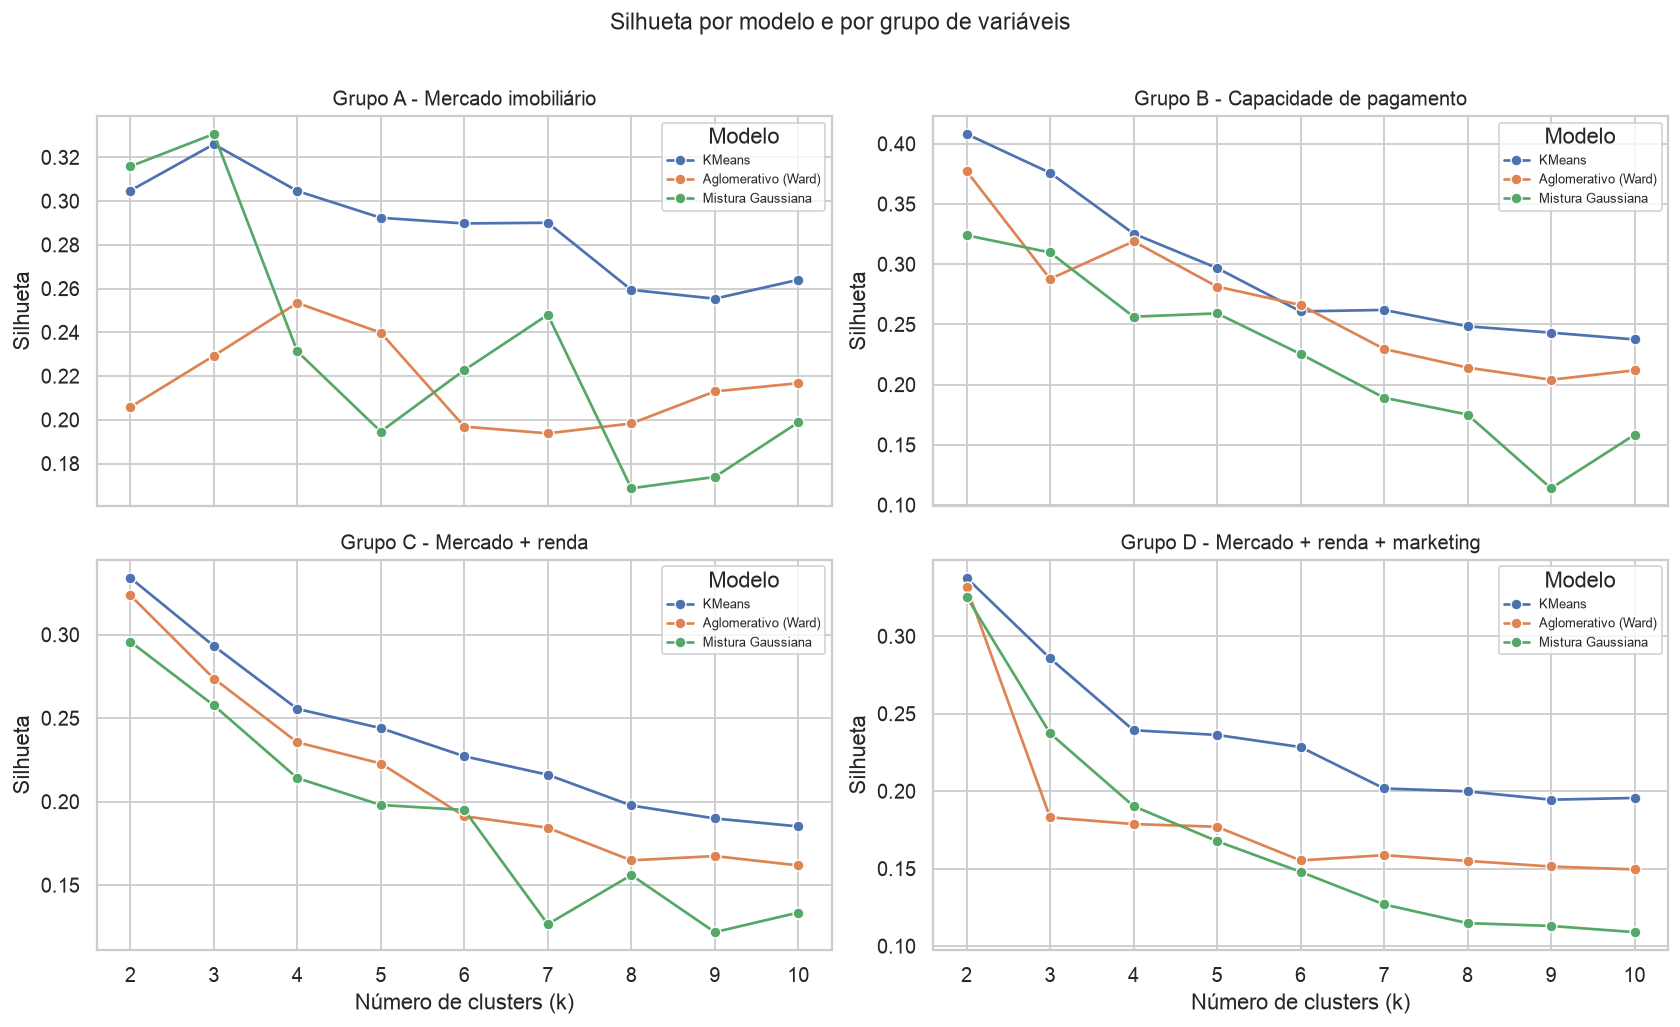

In [12]:
figura('05_comparacao_modelos')

In [13]:
tabela('09_candidatos_no_cotovelo')[['grupo','nome_grupo','nome_modelo','k','silhueta','davies_bouldin','calinski_harabasz','menor_cluster']]

,grupo,nome_grupo,nome_modelo,k,silhueta,davies_bouldin,calinski_harabasz,menor_cluster
0,B,Capacidade de pagamento,KMeans,4,0.325403,1.041928,474.708568,79
1,B,Capacidade de pagamento,Aglomerativo (Ward),4,0.318937,1.090198,423.147819,49
2,A,Mercado imobiliário,KMeans,4,0.304609,1.059685,311.734172,86
3,B,Capacidade de pagamento,Mistura Gaussiana,4,0.256380,1.274557,296.231568,49
4,A,Mercado imobiliário,Aglomerativo (Ward),4,0.253410,1.218729,238.371230,40
5,C,Mercado + renda,KMeans,5,0.244021,1.306644,273.657968,97
6,D,Mercado + renda + marketing,KMeans,5,0.236293,1.325127,283.777968,73
7,A,Mercado imobiliário,Mistura Gaussiana,4,0.231248,1.463312,200.069972,68
8,C,Mercado + renda,Aglomerativo (Ward),5,0.222848,1.377566,234.966394,36
9,C,Mercado + renda,Mistura Gaussiana,5,0.197982,1.482672,199.364799,70


### Qual grupo de variáveis ganha?

A silhueta pura premia espaços com menos variáveis e mais redundantes. Os grupos A e B, sozinhos, não respondem à pergunta: um só tem mercado, o outro só tem renda. A escolha final fica entre C e D, e o desempate é estabilidade no bootstrap.

In [14]:
tabela('09b_escolha_do_modelo')

,grupo,nome_grupo,nome_modelo,k,silhueta,estabilidade_bootstrap,menor_cluster,responde_a_pergunta,escolhido
0,D,Mercado + renda + marketing,KMeans,5,0.236293,0.8375,73,True,True
1,C,Mercado + renda,KMeans,5,0.244021,0.7024,97,True,False


## 6. O teste que importa: o cluster ganha de geografia e de porte?

Todos os agrupamentos avaliados no mesmo espaço de variáveis, então a silhueta é comparável.

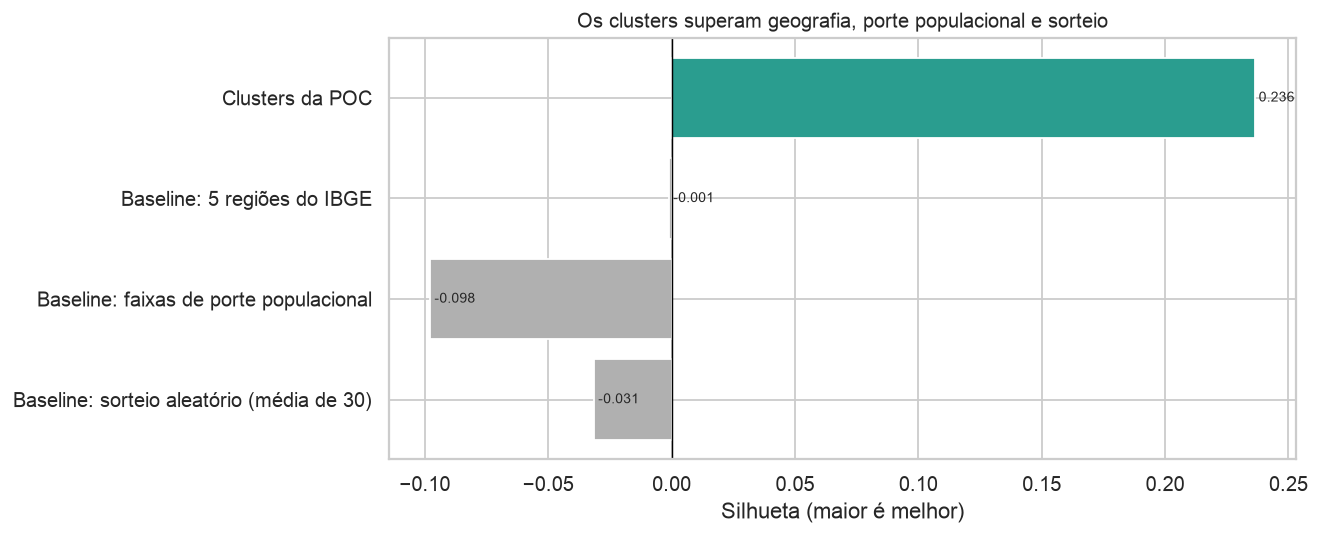

In [15]:
figura('06_baselines')

In [16]:
tabela('11_baselines_modelo_final')

,agrupamento,n_grupos,silhueta,rand_ajustado_vs_cluster
0,Clusters da POC,5,0.2363,1.0000
1,Baseline: 5 regiões do IBGE,5,-0.0010,0.1850
2,Baseline: faixas de porte populacional,5,-0.0978,0.0322
3,Baseline: sorteio aleatório (média de 30),5,-0.0314,-0.0001


Comparação dos quatro grupos contra os baselines:

In [17]:
tabela('10_baselines_por_grupo').pivot_table(index=['grupo','nome_grupo','k'], columns='agrupamento', values='silhueta').round(3)

,,agrupamento,Baseline: 5 regiões do IBGE,Baseline: faixas de porte populacional,Baseline: sorteio aleatório (média de 30),Clusters da POC
grupo,nome_grupo,k,,,,
A,Mercado imobiliário,4,-0.091,-0.167,-0.026,0.305
B,Capacidade de pagamento,4,0.015,-0.077,-0.028,0.325
C,Mercado + renda,5,0.005,-0.080,-0.030,0.244
D,Mercado + renda + marketing,5,-0.001,-0.098,-0.031,0.236
E,Mercado + risco + concorrência + demanda,5,0.048,-0.100,-0.030,0.184


## 7. Robustez

In [18]:
display(Markdown('**Bootstrap** (reamostras de 80% dos municípios):'))
display(tabela('13_estabilidade_bootstrap'))
display(Markdown('**Dez sementes diferentes:**'))
display(tabela('12_estabilidade_sementes'))

**Bootstrap** (reamostras de 80% dos municípios):

,modelo,k,metodo,fracao_reamostrada,n_comparacoes,rand_ajustado_medio,rand_ajustado_desvio,rand_ajustado_p5,rand_ajustado_p95
0,KMeans,5,subamostragem sem reposição,0.8,99,0.8473,0.1067,0.6677,0.9837


**Dez sementes diferentes:**

,semente,rand_ajustado_vs_referencia,silhueta
0,42,1.0000,0.2363
1,43,0.9942,0.2360
2,44,0.9837,0.2370
3,45,1.0000,0.2363
4,46,0.9883,0.2369
5,47,1.0000,0.2363
6,48,0.9837,0.2370
7,49,0.9883,0.2369
8,50,0.9837,0.2370
9,51,0.9883,0.2369


### Ablação: quanto cada variável sustenta a separação

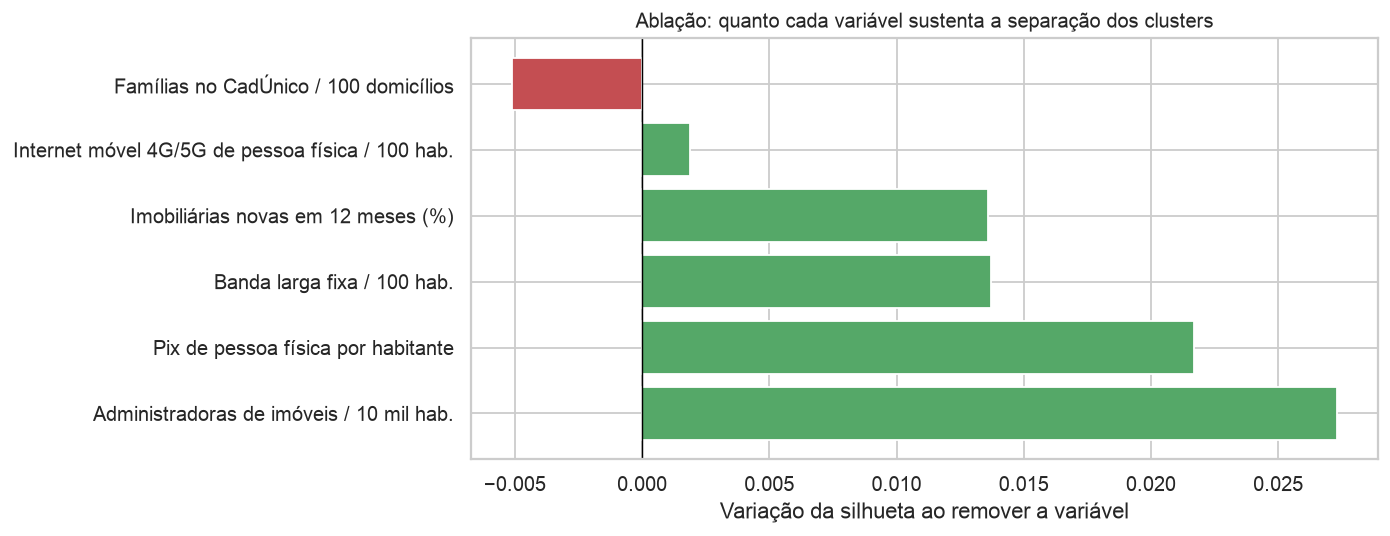

In [19]:
figura('11_ablacao')

In [20]:
tabela('14_ablacao')[['rotulo','silhueta_sem_ela','silhueta_completa','variacao','rand_ajustado_vs_completo']]

,rotulo,silhueta_sem_ela,silhueta_completa,variacao,rand_ajustado_vs_completo
0,Famílias no CadÚnico / 100 domicílios,0.2312,0.2363,-0.0051,0.6410
1,Internet móvel 4G/5G de pessoa física / 100 hab.,0.2382,0.2363,0.0019,0.7111
2,Imobiliárias novas em 12 meses (%),0.2499,0.2363,0.0136,0.5946
3,Banda larga fixa / 100 hab.,0.2500,0.2363,0.0137,0.7706
4,Pix de pessoa física por habitante,0.2580,0.2363,0.0217,0.7184
5,Administradoras de imóveis / 10 mil hab.,0.2636,0.2363,0.0273,0.6396


## 9. Os tipos de praça encontrados

In [21]:
tabela('16_tamanho_clusters').merge(tabela('22_valor_para_a_loft')[['cluster','nome']], on='cluster')[['cluster','nome','municipios','municipios_pct','populacao_pct','populacao_mediana']]

,cluster,nome,municipios,municipios_pct,populacao_pct,populacao_mediana
0,0,Praça em formação,73,10.6,4.9,80435.0
1,1,Praça intermediária conectada,219,31.9,19.2,98241.0
2,2,Praça popular de grande porte,167,24.3,23.7,119224.0
3,3,Praça sem mercado formal,97,14.1,4.8,64350.0
4,4,Praça madura de locação,131,19.1,47.5,221023.0


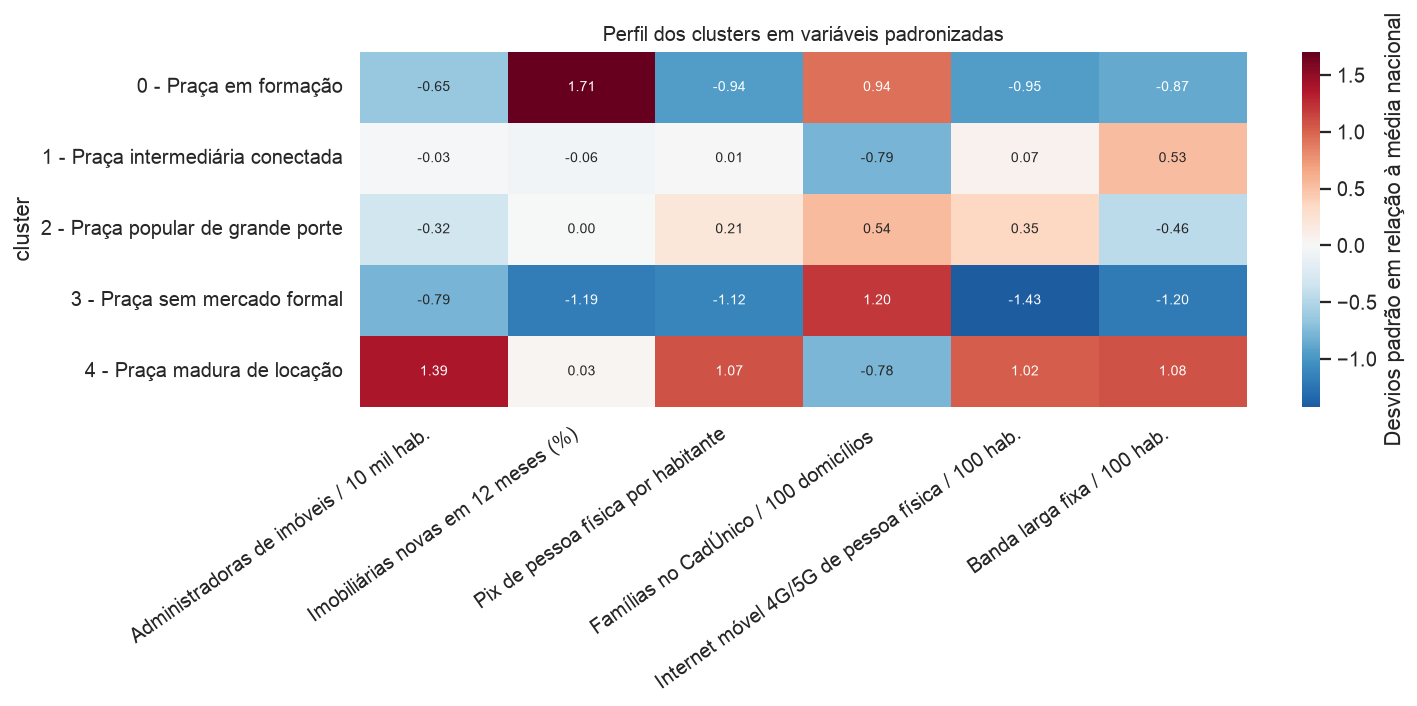

In [22]:
figura('07_perfil_clusters')

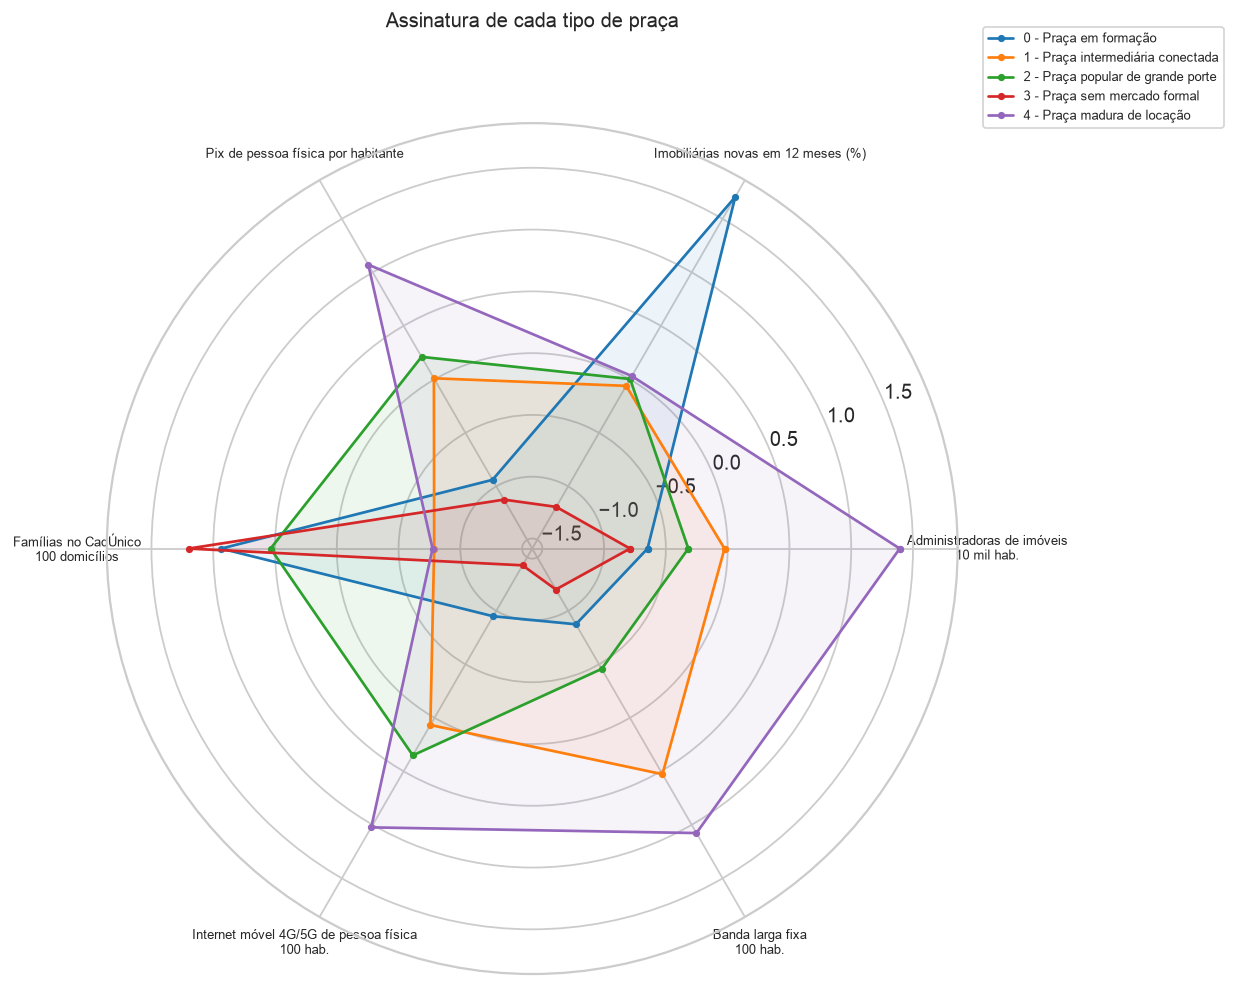

In [23]:
figura('08_radar_clusters')

In [24]:
tabela('17_marcas_dos_clusters')

,cluster,nome,marcas_do_cluster
0,0,Praça em formação,Imobiliárias novas em 12 meses (%): +1.71 desvios; Internet móvel ...
1,1,Praça intermediária conectada,Famílias no CadÚnico / 100 domicílios: -0.79 desvios; Banda larga ...
2,2,Praça popular de grande porte,Famílias no CadÚnico / 100 domicílios: +0.54 desvios; Banda larga ...
3,3,Praça sem mercado formal,Internet móvel 4G/5G de pessoa física / 100 hab.: -1.43 desvios; F...
4,4,Praça madura de locação,Administradoras de imóveis / 10 mil hab.: +1.39 desvios; Banda lar...


### Mapa do Brasil por tipo de praça

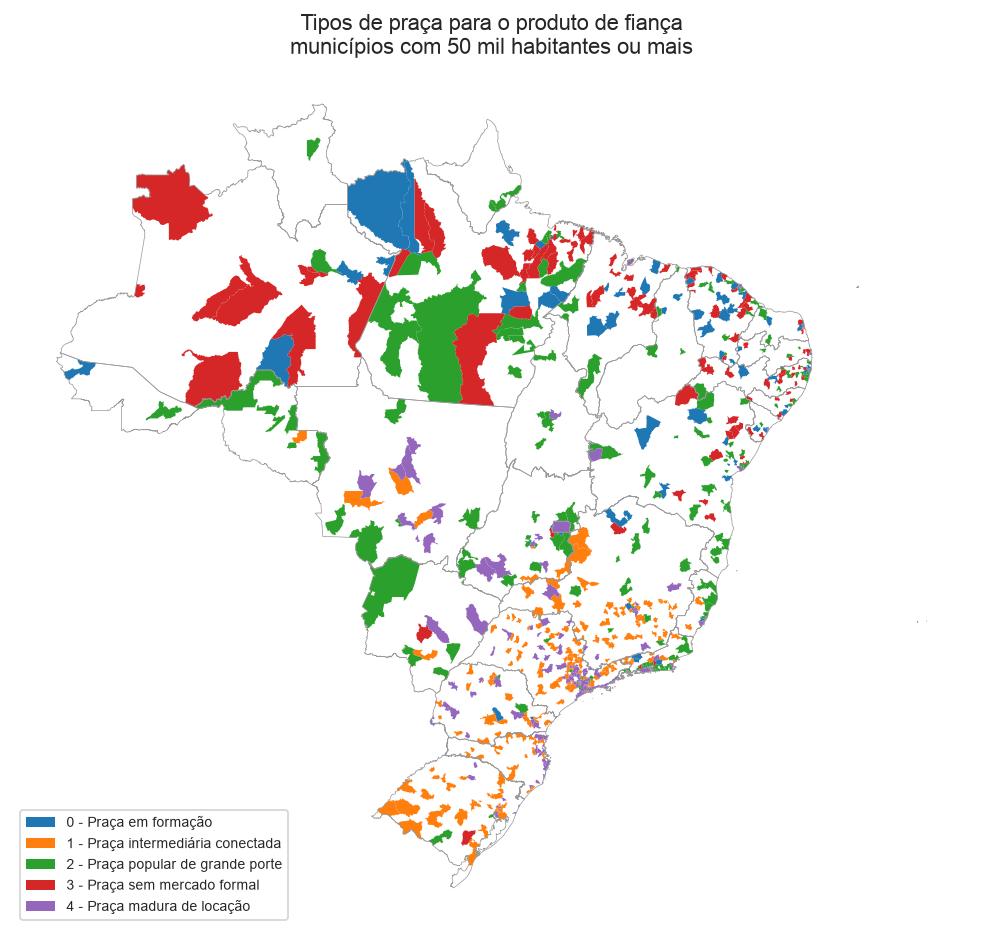

In [25]:
figura('09_mapa_clusters')

### Onde colocar o próximo real

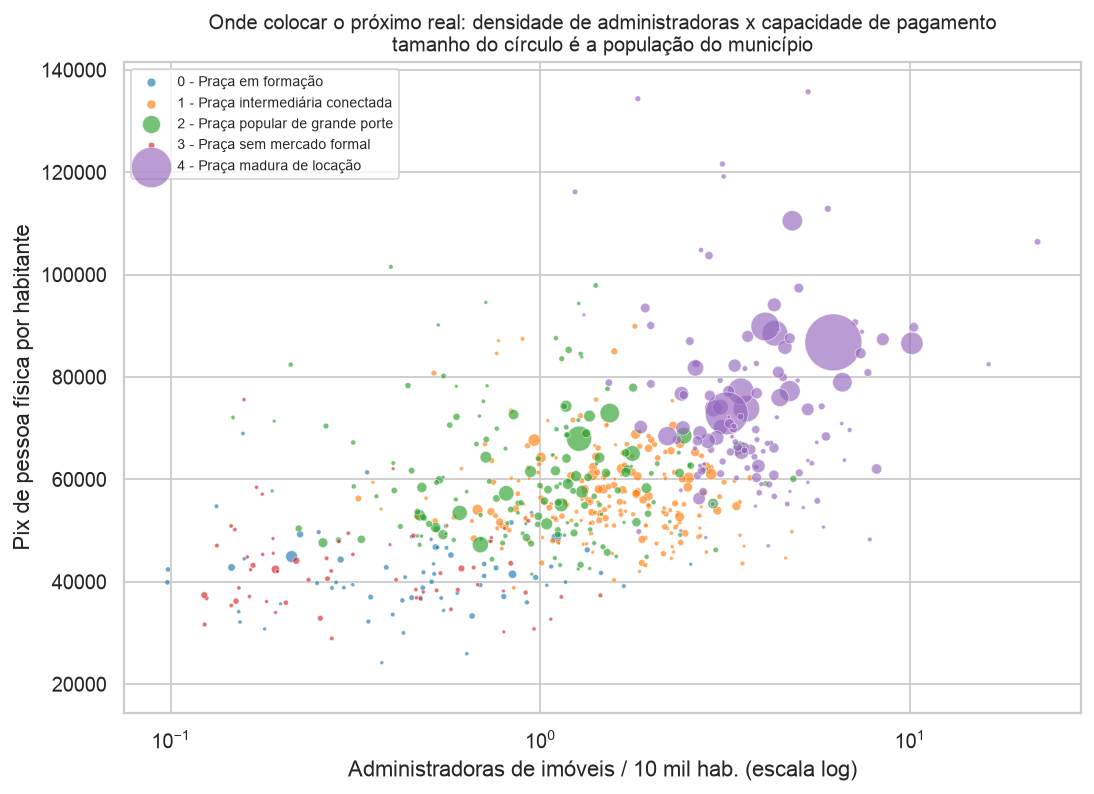

In [26]:
figura('10_mapa_de_decisao')

### Os dez maiores municípios de cada cluster

In [27]:
top = tabela('18_top_municipios')
for c in sorted(top.cluster.unique()):
    nome = tabela('22_valor_para_a_loft').set_index('cluster').loc[c,'nome']
    display(Markdown(f'**Cluster {c} — {nome}**'))
    display(top[top.cluster==c][['posicao','municipio','sigla_uf','populacao','administradoras_10k','pix_pf_por_hab']])

**Cluster 0 — Praça em formação**

,posicao,municipio,sigla_uf,populacao,administradoras_10k,pix_pf_por_hab
0,1,Belford Roxo,RJ,518442,0.21,44924.09
1,2,Caucaia,CE,380944,1.10,48570.56
2,3,Águas Lindas de Goiás,GO,249978,0.84,41468.56
3,4,Nossa Senhora do Socorro,SE,205611,0.15,42799.22
4,5,Mesquita,RJ,178780,0.22,49286.92
5,6,Abaetetuba,PA,173638,0.29,44339.28
6,7,Paço do Lumiar,MA,153903,0.52,46789.11
7,8,Crato,CE,139781,0.57,45216.45
8,9,Itapipoca,CE,137795,0.65,33328.16
9,10,Almirante Tamandaré,PR,127031,1.34,46233.71


**Cluster 1 — Praça intermediária conectada**

,posicao,municipio,sigla_uf,populacao,administradoras_10k,pix_pf_por_hab
10,1,Aparecida de Goiânia,GO,560996,0.96,67677.78
11,2,Caxias do Sul,RS,479604,2.90,61038.81
12,3,Mogi das Cruzes,SP,472255,2.52,60315.64
13,4,Betim,MG,433902,1.38,60853.61
14,5,Mauá,SP,429064,0.68,54061.92
15,6,Diadema,SP,403802,1.66,62094.18
16,7,Carapicuíba,SP,398772,1.00,64278.55
17,8,Canoas,RS,359845,2.81,62437.92
18,9,Uberaba,MG,359275,1.81,68816.31
19,10,São Vicente,SP,338253,1.48,58102.82


**Cluster 2 — Praça popular de grande porte**

,posicao,municipio,sigla_uf,populacao,administradoras_10k,pix_pf_por_hab
20,1,Manaus,AM,2327101,1.27,67956.62
21,2,Belém,PA,1396157,1.54,72959.84
22,3,Maceió,AL,995134,2.44,68543.32
23,4,São Gonçalo,RJ,959977,0.69,47248.93
24,5,Teresina,PI,908012,1.77,65061.46
25,6,Duque de Caxias,RJ,866167,0.81,57285.45
26,7,Nova Iguaçu,RJ,843367,0.60,53463.26
27,8,Jaboatão dos Guararapes,PE,685222,1.14,55016.95
28,9,Feira de Santana,BA,663408,3.45,66219.48
29,10,Serra,ES,586901,1.29,57579.15


**Cluster 3 — Praça sem mercado formal**

,posicao,municipio,sigla_uf,populacao,administradoras_10k,pix_pf_por_hab
30,1,São José de Ribamar,MA,260695,0.19,42427.89
31,2,Timon,MA,183123,0.22,44125.56
32,3,Caxias,MA,163650,0.61,42603.82
33,4,Santa Rita,PB,162488,0.12,37400.60
34,5,Cametá,PA,145843,0.00,32538.98
35,6,Bragança,PA,133268,0.15,36213.85
36,7,Marituba,PA,119859,0.17,43207.57
37,8,Codó,MA,118272,0.25,32878.97
38,9,Manacapuru,AM,113042,0.27,40586.18
39,10,Maranguape,CE,108323,0.83,43603.11


**Cluster 4 — Praça madura de locação**

,posicao,municipio,sigla_uf,populacao,administradoras_10k,pix_pf_por_hab
40,1,São Paulo,SP,11911337,6.20,86772.87
41,2,Rio de Janeiro,RJ,6731133,3.19,72904.49
42,3,Brasília,DF,3009996,4.06,89877.91
43,4,Fortaleza,CE,2582360,3.61,73833.43
44,5,Salvador,BA,2559945,3.48,77224.58
45,6,Belo Horizonte,MG,2415451,4.31,88564.84
46,7,Curitiba,PR,1832183,10.12,86597.29
47,8,Recife,PE,1588983,4.73,77266.09
48,9,Goiânia,GO,1511709,4.80,110531.06
49,10,Porto Alegre,RS,1388791,6.56,78987.32


### Validação externa: as descritoras

Estas variáveis **não entraram no modelo**. Se elas ordenam os clusters de forma coerente, é sinal de que os grupos capturaram algo real.

In [28]:
tabela('21_descritoras_por_cluster')

,cluster,domicilios_alugados_pct_uf,inadimplencia_pf_uf,fipezap_aluguel,trends_fianca_uf,motos_por_hab,financiamento_imob_per_capita,populacao,imobiliarias_10k,veiculos_por_hab
0,0,20.26,4.98,NaN,14.75,0.16,1914.93,99668.21,0.83,0.13
1,1,25.37,3.88,20.73,45.14,0.15,5661.90,131108.18,4.12,0.40
2,2,22.20,4.86,50.92,22.63,0.18,3385.95,211671.66,2.02,0.23
3,3,19.17,5.20,NaN,11.87,0.16,1271.22,73216.67,0.51,0.10
4,4,26.39,3.97,49.16,42.35,0.14,9686.75,541032.07,11.73,0.40


### Composição por região e por porte

Se os clusters fossem só geografia ou só tamanho, estas tabelas seriam diagonais.

In [29]:
display(tabela('19_composicao_regiao'))
display(tabela('20_composicao_porte'))

,cluster,Centro-Oeste,Nordeste,Norte,Sudeste,Sul
0,0,4.1,64.4,16.4,12.3,2.7
1,1,3.7,0.5,0.5,60.3,35.2
2,2,12.6,39.5,18.0,27.5,2.4
3,3,2.1,62.9,30.9,3.1,1.0
4,4,11.5,7.6,0.8,52.7,27.5


,cluster,50 a 100 mil,100 a 250 mil,250 a 500 mil,500 mil a 1 milhão,1 milhão ou mais
0,0,69.9,27.4,1.4,1.4,0.0
1,1,51.6,36.5,11.4,0.5,0.0
2,2,39.5,37.1,15.0,7.2,1.2
3,3,89.7,9.3,1.0,0.0,0.0
4,4,24.4,31.3,19.1,15.3,9.9


## 7. O cluster serve como variável de um modelo futuro?

Separação e estabilidade dizem que o agrupamento é consistente. Não dizem se ele é **útil**.

A pergunta certa **não** é se o cluster substitui a geografia — é se ele **acrescenta** algo a ela. No Brasil quase toda variável socioeconômica municipal é muito explicada pela região, então exigir que um agrupamento derrote a geografia é exigir que ele seja um proxy melhor de desigualdade regional, que não é a função dele.

Teste: R² **ajustado** de `região + porte` contra `região + porte + cluster`, em variáveis municipais que ficaram **fora** do modelo. Ajustado para não premiar só o aumento de parâmetros.

In [30]:
inc = tabela('25_valor_incremental_do_cluster')
display(Markdown(f"**O cluster acrescenta informação em {int(inc.o_cluster_acrescenta.sum())} de {len(inc)} variáveis retidas.** "
                 f"Ganho médio no R² ajustado: **{inc.ganho.mean():+.4f}**. Em nenhuma ele piora."))
inc[['rotulo','r2_regiao_e_porte','r2_com_o_cluster','ganho','o_cluster_acrescenta']]

**O cluster acrescenta informação em 15 de 15 variáveis retidas.** Ganho médio no R² ajustado: **+0.0435**. Em nenhuma ele piora.

,rotulo,r2_regiao_e_porte,r2_com_o_cluster,ganho,o_cluster_acrescenta
0,Corretores de seguros / 10 mil hab.,0.4040,0.5517,0.1478,True
1,Imobiliárias e corretoras / 10 mil hab.,0.1430,0.2825,0.1395,True
2,Veículos por habitante,0.7353,0.8116,0.0763,True
3,Motocicletas por habitante,0.1590,0.2239,0.0649,True
4,Salário mediano de admissão (R$),0.5579,0.6044,0.0465,True
5,Crescimento da população em 1 ano (%),0.2272,0.2737,0.0465,True
6,Financiamento imobiliário per capita (R$),0.1375,0.1641,0.0266,True
7,Admissões de 18 a 30 anos (%),0.3900,0.4132,0.0232,True
8,Saldo de emprego / admissões em 12 meses (%),0.1509,0.1740,0.0231,True
9,Domicílios alugados na UF (%),0.5466,0.5630,0.0164,True


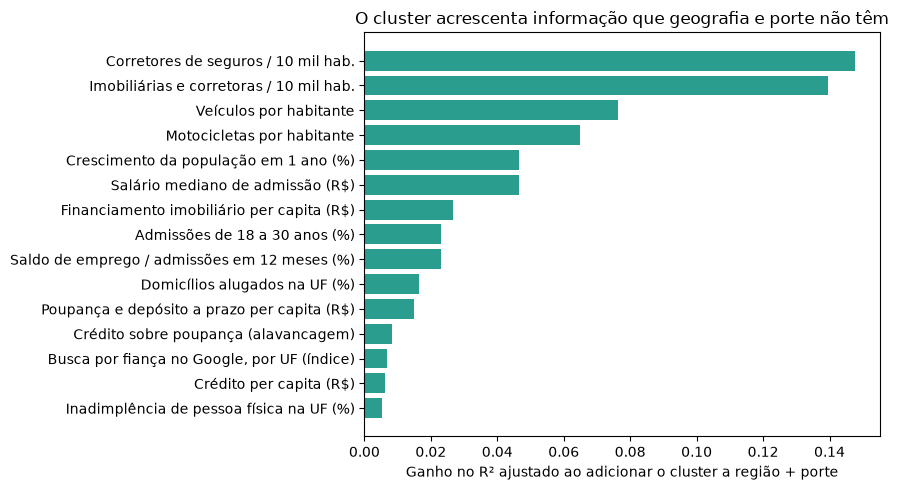

In [31]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(9, 5))
d = inc.sort_values('ganho')
ax.barh(d.rotulo, d.ganho, color='#2A9D8F')
ax.set_xlabel('Ganho no R² ajustado ao adicionar o cluster a região + porte')
ax.set_title('O cluster acrescenta informação que geografia e porte não têm')
plt.tight_layout(); plt.show()

### O caminho até esse resultado

O primeiro teste feito foi outro: pedir que o cluster **vencesse** a região ao explicar as mesmas variáveis retidas. Nesse formato o cluster perdia (2 de 7, ganho médio -0,011), e a conclusão parecia ser que o agrupamento não servia para nada.

O teste estava mal formulado. A função da segmentação é separar praças que devem receber o mesmo tratamento de mídia, e para isso o que importa é **informação incremental**, não substituição.

## 8. O grupo E: testamos uma especificação só de fiança

Depois do primeiro resultado negativo, montamos um grupo novo com variáveis específicas do mercado de fiança, que não são nível socioeconômico geral:

- **alavancagem** (crédito sobre poupança) — risco de inadimplência por município, que no SCR só existe por UF
- **reserva per capita** (poupança + depósito a prazo) — colchão que sustenta o aluguel
- **corretores de seguros / 10 mil hab.** — oferta local do seguro-fiança, o produto concorrente
- **crescimento da população em 1 ano** — motor da demanda de locação
- **admissões de 18 a 30 anos** — a faixa que aluga

O grupo E **perdeu** em separação. Está registrado porque um experimento que falha também é resultado: mostra que as variáveis de risco e demanda, embora certas conceitualmente, são mais ruidosas.

In [32]:
cand = tabela('09_candidatos_no_cotovelo')
cand[['grupo','nome_grupo','nome_modelo','k','silhueta','davies_bouldin','menor_cluster']].round(3)

,grupo,nome_grupo,nome_modelo,k,silhueta,davies_bouldin,menor_cluster
0,B,Capacidade de pagamento,KMeans,4,0.325,1.042,79
1,B,Capacidade de pagamento,Aglomerativo (Ward),4,0.319,1.090,49
2,A,Mercado imobiliário,KMeans,4,0.305,1.060,86
3,B,Capacidade de pagamento,Mistura Gaussiana,4,0.256,1.275,49
4,A,Mercado imobiliário,Aglomerativo (Ward),4,0.253,1.219,40
5,C,Mercado + renda,KMeans,5,0.244,1.307,97
6,D,Mercado + renda + marketing,KMeans,5,0.236,1.325,73
7,A,Mercado imobiliário,Mistura Gaussiana,4,0.231,1.463,68
8,C,Mercado + renda,Aglomerativo (Ward),5,0.223,1.378,36
9,C,Mercado + renda,Mistura Gaussiana,5,0.198,1.483,70


## 9. Valor para a Loft

In [33]:
valor = tabela('22_valor_para_a_loft')
for _, r in valor.iterrows():
    display(Markdown(f"### Cluster {r.cluster} — {r['nome']}\n\n"
        f"{r.municipios} municípios, {r.populacao_pct}% da população do universo.\n\n"
        f"**O que significa para a fiança:** {r.o_que_significa_para_a_fianca}\n\n"
        f"**Ação de marketing sugerida:** {r.acao_de_marketing_sugerida}"))

### Cluster 0 — Praça em formação

73 municípios, 4.9% da população do universo.

**O que significa para a fiança:** Muita imobiliária abrindo agora: o mercado está se organizando e as empresas novas ainda não têm processo de garantia definido.

**Ação de marketing sugerida:** Momento de entrada. Mídia de educação de produto para imobiliária nova, custo por lead ainda baixo.

### Cluster 1 — Praça intermediária conectada

219 municípios, 19.2% da população do universo.

**O que significa para a fiança:** Mercado e renda medianos, mas alcance digital alto: dá para testar barato com boa cobertura de audiência.

**Ação de marketing sugerida:** Praça de teste A/B de criativo. Verba pequena e recorrente em Meta e TikTok para aprender antes de levar o aprendizado às praças maduras.

### Cluster 2 — Praça popular de grande porte

167 municípios, 23.7% da população do universo.

**O que significa para a fiança:** Cidade grande com muita gente e muito contrato potencial, mas o mercado formal de locação é raso para o tamanho dela e a vulnerabilidade está acima da média. A fiança cabe, só que o gargalo não é demanda: é falta de imobiliária organizada para vender.

**Ação de marketing sugerida:** Praça de volume, mas de captação antes de conversão. Mídia para recrutar imobiliária nova, com meta de custo por imobiliária cadastrada, não por lead de inquilino. Verba média e análise de risco mais rígida na esteira.

### Cluster 3 — Praça sem mercado formal

97 municípios, 4.8% da população do universo.

**O que significa para a fiança:** Praticamente não existe administradora formal e a vulnerabilidade é alta: não há cliente B2B para vender e o risco de inadimplência é o maior.

**Ação de marketing sugerida:** Zero verba de mídia paga. Praça de exclusão no planejamento.

### Cluster 4 — Praça madura de locação

131 municípios, 47.5% da população do universo.

**O que significa para a fiança:** Muitas administradoras e inquilino com capacidade de pagar: o risco da fiança é baixo e o cliente B2B já existe e já vende locação.

**Ação de marketing sugerida:** Mídia de conversão para imobiliária (Meta e Google Search em segmentação B2B), com verba concentrada e meta de custo por lead.

## 11. Limitações e próximos passos

Estão detalhados em [`reports/poc_clusterizacao.md`](../reports/poc_clusterizacao.md).

As três principais:

1. **Sem dado interno da Loft.** Descrevemos o mercado, não o desempenho da Loft nele.
2. **Os grupos não são naturais.** São um corte útil de um contínuo; a defesa deles é a comparação com os baselines.
3. **CNAE não separa locação de venda**, por isso as praças de veraneio aparecem com densidade altíssima de imobiliária sem serem mercado de fiança.